In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
directory = 'C:\\Users\\Aren Simmons\\OneDrive - Smarter Balanced UCSC\\Desktop\\data_files'


In [21]:
#Reading in the data
oct_19 = pd.read_csv(os.path.join(directory, '2019-Oct.csv'))
nov_19 = pd.read_csv(os.path.join(directory, '2019-Nov.csv'))
dec_19 = pd.read_csv(os.path.join(directory, '2019-Dec.csv'))
jan_20 = pd.read_csv(os.path.join(directory, '2020-Jan.csv'))
feb_20 = pd.read_csv(os.path.join(directory, '2020-Feb.csv'))

## Data Quality Check:
The first thing we need to do is examine the data for each table to understand what we're working with and check for missing values, outliers, etc. Below are provided each column, their respective data and how they relate to one another.

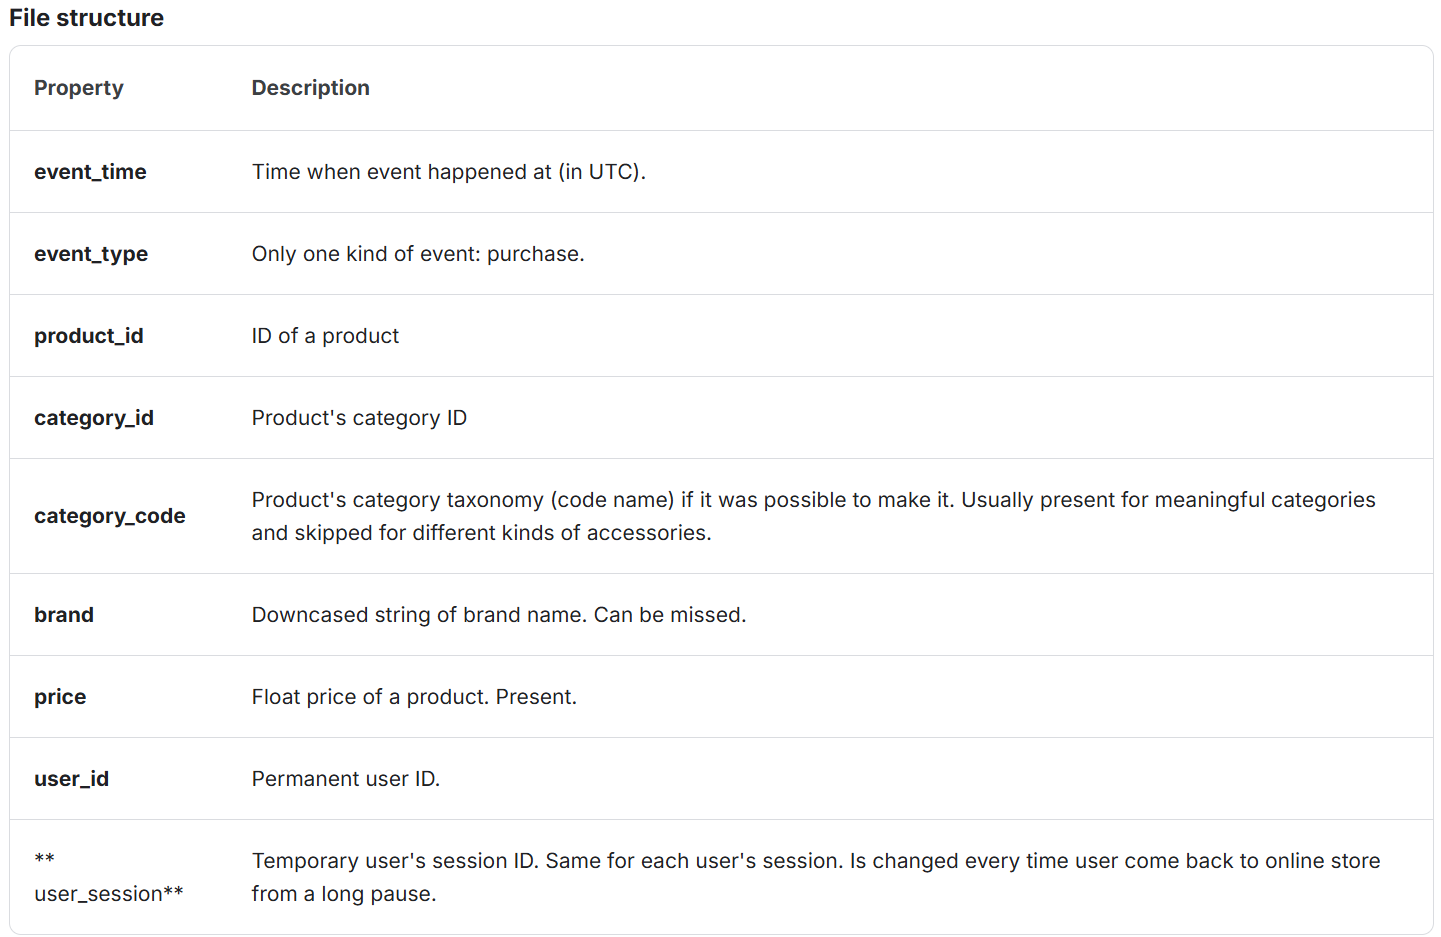

In [23]:
#Doing a rough data check using october 2019 as a data sample
oct_19

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,cart,5773203,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
1,2019-10-01 00:00:03 UTC,cart,5773353,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
2,2019-10-01 00:00:07 UTC,cart,5881589,2151191071051219817,NaN,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9
3,2019-10-01 00:00:07 UTC,cart,5723490,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
4,2019-10-01 00:00:15 UTC,cart,5881449,1487580013522845895,NaN,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9
...,...,...,...,...,...,...,...,...,...
4102278,2019-10-31 23:59:25 UTC,remove_from_cart,5848062,1526733091857498510,NaN,NaN,9.21,429913900,2f0bff3c-252f-4fe6-afcd-5d8a6a92839a
4102279,2019-10-31 23:59:30 UTC,view,5885631,1783999064103190764,NaN,NaN,15.48,556138645,57ed222e-a54a-4907-9944-5a875c2d7f4f
4102280,2019-10-31 23:59:34 UTC,view,5784898,1487580009143992338,NaN,NaN,1.78,564441099,8cbf1746-2d46-4169-afb1-b5fa38ee1ba4
4102281,2019-10-31 23:59:36 UTC,view,5870838,1487580007675986893,NaN,milv,0.79,429913900,2f0bff3c-252f-4fe6-afcd-5d8a6a92839a


In [24]:
oct_19.info(show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4102283 entries, 0 to 4102282
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   event_time     4102283 non-null  object 
 1   event_type     4102283 non-null  object 
 2   product_id     4102283 non-null  int64  
 3   category_id    4102283 non-null  int64  
 4   category_code  67477 non-null    object 
 5   brand          2443022 non-null  object 
 6   price          4102283 non-null  float64
 7   user_id        4102283 non-null  int64  
 8   user_session   4101646 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 281.7+ MB


In [25]:
oct_19.brand.value_counts(dropna = False)

brand
NaN        1659261
runail      306239
irisk       226589
masura      195170
grattol     132130
            ...   
dessata          2
gena             2
pueen            1
shifei           1
ikoo             1
Name: count, Length: 241, dtype: int64

In [26]:
oct_19.category_code.value_counts(dropna = False)

category_code
NaN                                       4034806
appliances.environment.vacuum               27732
stationery.cartrige                         13459
apparel.glove                                7430
furniture.living_room.cabinet                6234
accessories.bag                              5848
furniture.bathroom.bath                      5018
appliances.personal.hair_cutter               828
accessories.cosmetic_bag                      642
appliances.environment.air_conditioner        161
furniture.living_room.chair                   123
sport.diving                                    2
Name: count, dtype: int64

In [27]:
#We see that there are a lot of NA values in both the brand and the category_code columns. I'll keep this in mind moving forward.

In [28]:
#From the event type we can see the type of events and their value counts. This is a good sign that our data is mostly intact and that we can see a meaningful funnel from views to purchase.
oct_19.event_type.value_counts()

event_type
view                1862164
cart                1232385
remove_from_cart     762110
purchase             245624
Name: count, dtype: int64

In [29]:
#Most of the data is categorical, except for the timestamps. This means that the only column that would contain outliers would be the price column.

In [30]:
oct_19.price.sort_values()

1924072    -79.37
3807737    -47.62
1519246    -47.62
436918     -47.62
3135434    -47.62
            ...  
2554724    307.60
1343631    307.60
1316527    307.60
2023799    307.60
979141     307.60
Name: price, Length: 4102283, dtype: float64

In [31]:
oct_19[oct_19['price'] < 0]

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
112860,2019-10-01 19:10:56 UTC,purchase,5716857,1487580014042939619,NaN,NaN,-23.81,552507528,dcdd60c6-1a70-442d-bfb2-0252879054ad
198302,2019-10-02 08:30:03 UTC,purchase,5716855,1487580014042939619,NaN,NaN,-7.94,550375225,5ddec778-9464-4514-914d-be7b751b8e2c
436918,2019-10-03 17:37:04 UTC,purchase,5716859,1487580014042939619,NaN,NaN,-47.62,555414763,479149eb-1807-4178-8f6b-87c642350735
443204,2019-10-03 18:25:39 UTC,purchase,5670257,1487580014042939619,NaN,NaN,-15.87,556383221,4333d203-bc4d-4d0d-a6e1-0ea3a97a28c1
1295556,2019-10-09 14:49:14 UTC,purchase,5716855,1487580014042939619,NaN,NaN,-7.94,514562574,fed2aeb4-0c75-44f7-9ca8-1a8be8214779
1426186,2019-10-10 14:33:29 UTC,purchase,5716855,1487580014042939619,NaN,NaN,-7.94,558797258,a406cf28-f04b-4361-8e6a-c62d36045e07
1519246,2019-10-11 10:27:19 UTC,purchase,5716859,1487580014042939619,NaN,NaN,-47.62,543647038,85e11d74-6583-4eab-b50c-ff86dbb25d97
1783312,2019-10-13 16:46:01 UTC,purchase,5716857,1487580014042939619,NaN,NaN,-23.81,559820267,f178c995-f004-4040-b26d-b1cca0f9657d
1924072,2019-10-14 17:33:24 UTC,purchase,5716861,1487580014042939619,NaN,NaN,-79.37,541122983,b60f777d-afca-4299-8548-273b810d6130
2143762,2019-10-16 11:41:06 UTC,purchase,5716857,1487580014042939619,NaN,NaN,-23.81,461943726,beefa8fb-a3d1-48ca-97e9-9c95b05ee997


In [32]:
# We can see that once sorted, the price ranges from -$79.37 to $307.70
# I'm going to remove the negative values as they don't make sense in this context. There aren't a lot of thes values and we can see that they are all purchases. I'd be willing to bet these are refunds.
# We can also see that the category_id is the same for all of these values, but the product_id is different. I'll keep this in mind moving forward. 

In [33]:
oct_19 = oct_19[oct_19['price'] > 0]

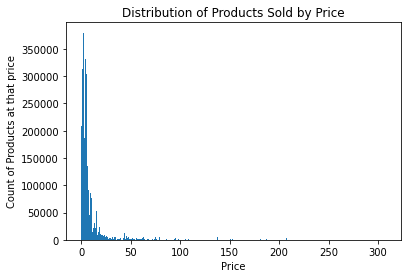

In [34]:
plt.hist(oct_19['price'], bins = 500)
plt.xlabel('Price')
plt.ylabel('Count of Products at that price')
plt.title('Distribution of Products Sold by Price')
plt.show()

In [35]:
# The view of the data is not very useful because there are outliers that skew our view. I would like to use the IQR (Interquartile range) to filter out the outliers to give us a better view. 
# I'll use the IQR because it is a robust measure of variability to exclude extreme outliers. 

In [36]:
Q1 = np.percentile(oct_19['price'], 25)
Q3 = np.percentile(oct_19['price'], 75)
IQR = Q3 - Q1

In [37]:
lower_threshold = Q1 - 1.5 * IQR
upper_threshold = Q3 + 1.5 * IQR

In [38]:
oct_19_lower = oct_19[oct_19['price'] > lower_threshold]
oct_19_no_outliers = oct_19_lower[oct_19_lower['price'] < upper_threshold]

In [39]:
oct_19_no_outliers

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,cart,5773203,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
1,2019-10-01 00:00:03 UTC,cart,5773353,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
2,2019-10-01 00:00:07 UTC,cart,5881589,2151191071051219817,NaN,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9
3,2019-10-01 00:00:07 UTC,cart,5723490,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
4,2019-10-01 00:00:15 UTC,cart,5881449,1487580013522845895,NaN,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9
...,...,...,...,...,...,...,...,...,...
4102276,2019-10-31 23:59:13 UTC,view,5848062,1526733091857498510,NaN,NaN,9.21,429913900,2f0bff3c-252f-4fe6-afcd-5d8a6a92839a
4102278,2019-10-31 23:59:25 UTC,remove_from_cart,5848062,1526733091857498510,NaN,NaN,9.21,429913900,2f0bff3c-252f-4fe6-afcd-5d8a6a92839a
4102280,2019-10-31 23:59:34 UTC,view,5784898,1487580009143992338,NaN,NaN,1.78,564441099,8cbf1746-2d46-4169-afb1-b5fa38ee1ba4
4102281,2019-10-31 23:59:36 UTC,view,5870838,1487580007675986893,NaN,milv,0.79,429913900,2f0bff3c-252f-4fe6-afcd-5d8a6a92839a


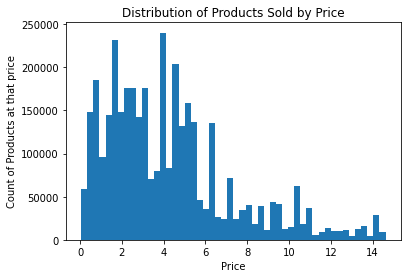

In [40]:
plt.hist(oct_19_no_outliers['price'], bins = 50)
plt.xlabel('Price')
plt.ylabel('Count of Products at that price')
plt.title('Distribution of Products Sold by Price')
plt.show()

In [41]:
# The data isn't normally distributed, however excluding the outliers we can see a much clearer picture of our data. 